## Strain diversity

Strain diversity is often hidden behind high genomic similarity, yet small differences in metabolic repertoires can translate into meaningful functional variation. By comparing genome-scale metabolic models using Jaccard distance, we can quantify how much metabolic potential is shared or unique across strains. This tutorial introduces a simple and effective framework to explore strain-level metabolic diversity through reaction-based similarity metrics, providing an entry point into functional comparative genomics.

In [1]:
import cobra
import os
import pandas as pd

The following function loads all metabolic models from a folder and represents each strain as a set of metabolic reactions.
In this way, each model is converted into a functional "fingerprint" based on its metabolic capabilities.

In [2]:
def load_models(folder):
    models = {}
    for f in os.listdir(folder):
        if f.endswith(".xml.gz"):
            model = cobra.io.read_sbml_model(os.path.join(folder, f))
            
            # We use reactions as functional features:
            # the presence or absence of a reaction reflects
            # the metabolic potential of each strain
            models[f.replace(".xml.gz","")] = set(r.id for r in model.reactions)
    return models


Load two groups of models generated with different reconstruction pipelines (e.g., CarveMe and CarveMeGut) to compare their metabolic composition



In [4]:
carveme_models = load_models("Amuniciphila/carveme/")
carvemegut_models = load_models("Amuniciphila/carvemegut/")

Build the global set of all reactions observed across all models. This represents the full functional space covered by the analyzed strains

In [7]:
all_sets = list(carveme_models.values()) + list(carvemegut_models.values())
all_reactions = sorted(set().union(*all_sets))

The following function creates a binary matrix (strain × reactions):
 1 = reaction present in the model
 0 = reaction absent
This matrix can be used to compute similarity metrics (e.g., Jaccard distance) and to perform clustering or comparative analyses of metabolic repertoires

In [8]:
def make_binary_df(models):
    df = pd.DataFrame(0, index=models.keys(), columns=all_reactions)
    for strain, rxns in models.items():
        df.loc[strain, list(rxns)] = 1
    return df

# Binary dataframes for the two sets of metabolic models
df_carveme = make_binary_df(carveme_models)
df_carvemegut = make_binary_df(carvemegut_models)

_____________

### Compute pairwise Jaccard distances for models drafted with CarveMe and CarveMeGut-Microbes

We convert the binary reaction matrix into a distance matrix using Jaccard distance.
This quantifies the functional similarity between strains based on the presence or absence of metabolic reactions.

In [9]:
from scipy.spatial.distance import pdist, squareform
import pandas as pd

dist_carveme = pd.DataFrame(
    squareform(pdist(df_carveme, metric="jaccard")),
    index=df_carveme.index,
    columns=df_carveme.index
)
dist_carveme.head()

dist_carvemegut = pd.DataFrame(
    squareform(pdist(df_carvemegut, metric="jaccard")),
    index=df_carvemegut.index,
    columns=df_carvemegut.index
)
dist_carvemegut.head()

,GUT_GENOME018436,GUT_GENOME039204,GUT_GENOME162207,GUT_GENOME208936,GUT_GENOME001998,GUT_GENOME078423,GUT_GENOME249548,GUT_GENOME234431,GUT_GENOME107086,GUT_GENOME051524,...,GUT_GENOME176181,GUT_GENOME068240,GUT_GENOME076970,GUT_GENOME279771,GUT_GENOME075654,GUT_GENOME106658,GUT_GENOME249849,GUT_GENOME103381,GUT_GENOME182915,GUT_GENOME249717
GUT_GENOME018436,0.000000,0.460606,0.416755,0.474257,0.467807,0.528282,0.427317,0.459854,0.366632,0.568647,...,0.453360,0.405622,0.385312,0.429293,0.364279,0.472306,0.361483,0.390171,0.462793,0.469556
GUT_GENOME039204,0.460606,0.000000,0.443601,0.420660,0.464361,0.540331,0.453731,0.433775,0.432821,0.559184,...,0.476386,0.411215,0.432624,0.470889,0.430723,0.470650,0.427692,0.435794,0.505155,0.506289
GUT_GENOME162207,0.416755,0.443601,0.000000,0.453674,0.415470,0.466112,0.470884,0.442200,0.424211,0.567427,...,0.434267,0.389903,0.417537,0.482402,0.418989,0.480851,0.425577,0.378610,0.412752,0.454545
GUT_GENOME208936,0.474257,0.420660,0.453674,0.000000,0.484663,0.551948,0.483591,0.455914,0.480826,0.549239,...,0.471487,0.427846,0.453017,0.462944,0.432540,0.444679,0.495146,0.424975,0.463874,0.497917
GUT_GENOME001998,0.467807,0.464361,0.415470,0.484663,0.000000,0.494869,0.509597,0.443469,0.412682,0.546859,...,0.488277,0.435005,0.488759,0.501002,0.436436,0.490683,0.464930,0.439960,0.455224,0.448802


### Visualize strain-level metabolic diversity with MDS

Here, we use Multi-Dimensional Scaling (MDS) to project the Jaccard distance matrices
into two dimensions. This allows us to visualize functional similarities and differences
between strains based on their metabolic reaction content.

Each point represents a strain, positioned based on metabolic similarity.
CarveMe and CarveMeGut models are plotted together for visual comparison.

/Users/arianna/miniconda3/envs/carve_fungi/lib/python3.8/site-packages/sklearn/manifold/_mds.py:298: FutureWarning: The default value of `normalized_stress` will change to `'auto'` in version 1.4. To suppress this warning, manually set the value of `normalized_stress`.
  warnings.warn(
/Users/arianna/miniconda3/envs/carve_fungi/lib/python3.8/site-packages/sklearn/manifold/_mds.py:298: FutureWarning: The default value of `normalized_stress` will change to `'auto'` in version 1.4. To suppress this warning, manually set the value of `normalized_stress`.
  warnings.warn(


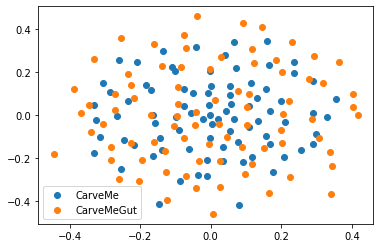

In [13]:
from sklearn.manifold import MDS
import matplotlib.pyplot as plt

mds = MDS(n_components=2, dissimilarity="precomputed", random_state=42)
coords_carveme = mds.fit_transform(dist_carveme)
coords_carvemegut = mds.fit_transform(dist_carvemegut)

plt.scatter(coords_carveme[:,0], coords_carveme[:,1], label="CarveMe")
plt.scatter(coords_carvemegut[:,0], coords_carvemegut[:,1], label="CarveMeGut")
plt.legend()
plt.show()


We can also use a clustermap to visualize pairwise Jaccard distances between CarveMe models.
Hierarchical clustering organizes strains based on shared and unique reactions,
highlighting patterns of metabolic similarity and functional divergence.

/Users/arianna/miniconda3/envs/carve_fungi/lib/python3.8/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/Users/arianna/miniconda3/envs/carve_fungi/lib/python3.8/site-packages/seaborn/matrix.py:530: ClusterWarning: scipy.cluster: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  linkage = hierarchy.linkage(self.array, method=self.method,


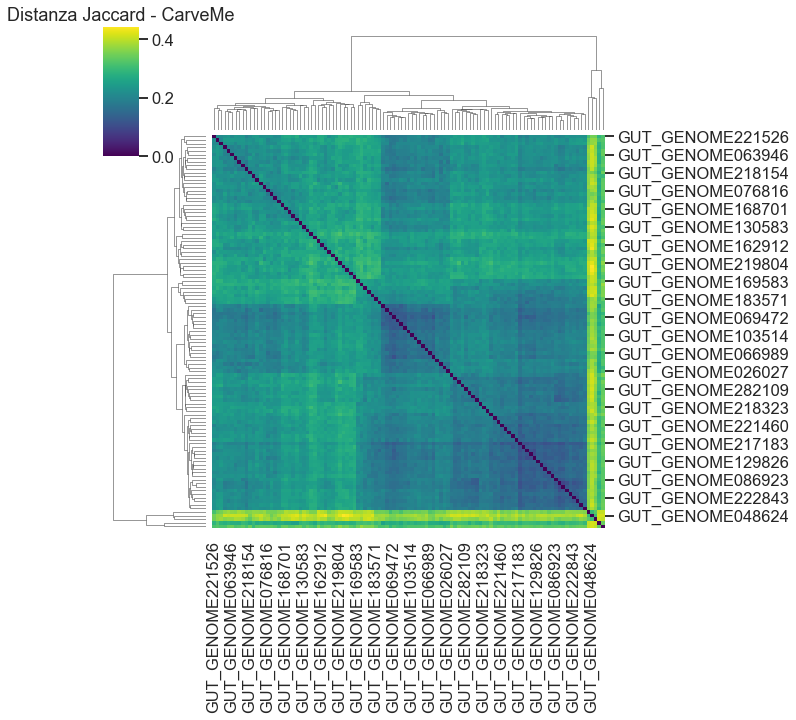

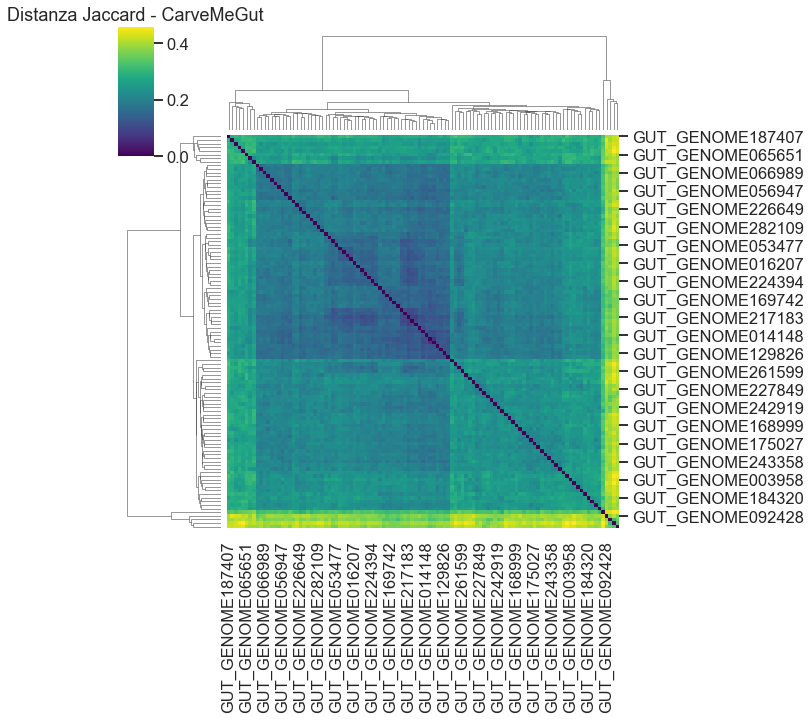

In [48]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.clustermap(dist_carveme, cmap="viridis", figsize=(10,10))
plt.title("Distanza Jaccard - CarveMe")
plt.show()

sns.clustermap(dist_carvemegut, cmap="viridis", figsize=(10,10))
plt.title("Distanza Jaccard - CarveMeGut")
plt.show()


### Compare pairwise metabolic distances between CarveMe and CarveMeGut-Microbes

To quantify strain-level metabolic diversity, we extract all pairwise Jaccard distances
from the distance matrices. Since the two datasets may differ slightly in size, 
we truncate to the smallest length to allow paired comparisons.

/Users/arianna/miniconda3/envs/carve_fungi/lib/python3.8/site-packages/seaborn/categorical.py:166: FutureWarning: Setting a gradient palette using color= is deprecated and will be removed in version 0.13. Set `palette='dark:black'` for same effect.
  warnings.warn(msg, FutureWarning)


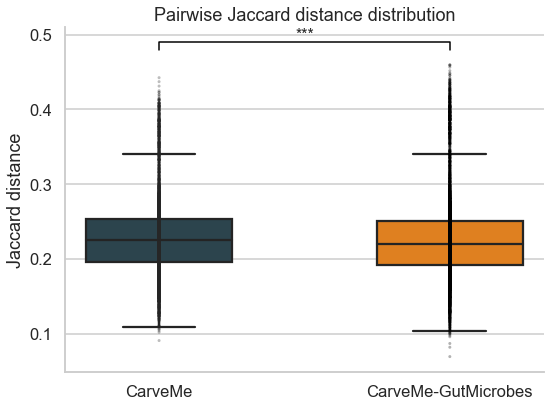

In [49]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import wilcoxon

sns.set_theme(style="whitegrid", context="talk")

def get_pairwise_distances(df_dist):
    iu = np.triu_indices_from(df_dist, k=1)
    return df_dist.values[iu]

carveme = get_pairwise_distances(dist_carveme)
carvemegut = get_pairwise_distances(dist_carvemegut)
min_len = min(len(carveme), len(carvemegut))
carveme = carveme[:min_len]
carvemegut = carvemegut[:min_len]

data = pd.DataFrame({
    "CarveMe": carveme,
    "CarveMe-GutMicrobes": carvemegut
})


### Perform statistical comparison and visualize pairwise Jaccard distance distribution

We use the paired Wilcoxon test to assess whether the distributions of pairwise Jaccard distances
differ significantly between the two reconstruction pipelines. Finally, we plot boxplots with overlaid individual points to show variability and outliers. Significance from the Wilcoxon test is indicated above the boxes.

In [ ]:
# Wilcoxon test (paired)
stat, pval = wilcoxon(carveme, carvemegut)

plt.figure(figsize=(8,6))

palette = ["#264653", "#ff8000"]

ax = sns.boxplot(data=data, palette=palette, width=0.5, showfliers=False)
sns.stripplot(data=data, color="black", alpha=0.3, size=3, jitter=False)

plt.ylabel("Jaccard distance")
plt.xlabel("")
plt.title("Pairwise Jaccard distance distribution")

# posizione per la linea del p-value
y_max = data.max().max()
y, h = y_max + 0.02, 0.01

if pval < 0.001:
    label = "***"
elif pval < 0.01:
    label = "**"
elif pval < 0.05:
    label = "*"
else:
    label = "ns"



x1, x2 = 0, 1
plt.plot([x1, x1, x2, x2], [y, y+h, y+h, y], lw=1.5, c="black")

plt.text((x1+x2)*0.5, y+h, label, ha="center", va="bottom", fontsize=16)

sns.despine()
plt.tight_layout()
plt.savefig('ecoli_strain.svg', dpi=300, bbox_inches="tight")

plt.show()

The end :) 